In [265]:
import os
import pandas as pd 
import numpy as np
from statsmodels import robust
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from scipy.stats import chi2_contingency

In [208]:
path = "C:\\Users\\idane\\PythonProjects\\GSAF_Matriz_ML.csv"
gsaf_df = pd.read_csv(path)
gsaf_df.columns = gsaf_df.columns.str.lower() # change all the letters in the column names to lower case
gsaf_df.columns = gsaf_df.columns.str.strip().str.lower() # remove leading and trailing whitespace from the column names and change all the letters to lower case

In [ ]:
# 3  Meta-Analysis of the Data

#3.1 File Metadata (From path)
file_size_mb = os.path.getsize(path) / (1000 * 1000)
print(f"File size: {file_size_mb} MB")

file_format = os.path.splitext(path)[1].upper().replace('.', '')
print(f"File format: {file_format}")

# 3.2 DataFrame Metadata (From gsaf_df)
display(gsaf_df.shape)
display(gsaf_df.columns)
display(gsaf_df.info())



File size: 2.026096 MB
File format: CSV


(5124, 37)

Index(['year', 'country', 'state', 'location', 'time', 'species', 'hour',
       'time_of_day', 'shark_size_meters', 'day', 'month', 'extracted_lat',
       'extracted_lon', 'temperature_2m_mean', 'precipitation_sum',
       'wind_speed_10m_max', 'wind_direction_10m_dominant', 'activity',
       'activity_clean', 'moon_illumination', 'moon_phase', 'act_diving',
       'act_fishing', 'act_other', 'act_surfing', 'act_swimming',
       'act_unknown', 'act_wading/standing', 'lua_full moon', 'lua_new moon',
       'lua_waning crescent', 'lua_waxing crescent',
       'temperature_2m_mean_scaled', 'precipitation_sum_scaled',
       'wind_speed_10m_max_scaled', 'wind_dir_sin', 'wind_dir_cos'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 5124 entries, 0 to 5123
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         5124 non-null   float64
 1   country                      5124 non-null   str    
 2   state                        5124 non-null   str    
 3   location                     5124 non-null   str    
 4   time                         5124 non-null   str    
 5   species                      5124 non-null   str    
 6   hour                         5124 non-null   str    
 7   time_of_day                  5124 non-null   str    
 8   shark_size_meters            5124 non-null   str    
 9   day                          5124 non-null   str    
 10  month                        5124 non-null   str    
 11  extracted_lat                5124 non-null   str    
 12  extracted_lon                5124 non-null   str    
 13  temperature_2m_mean          

None

In [210]:
# 4 Data Quality and Completeness

In [211]:
# 4.1 Missing Values
print("Missing values per column:")
display(gsaf_df.astype(str).apply(lambda col: col.str.lower().eq('unknown')).sum())
print("Total missing values in the DataFrame:")
display(gsaf_df.astype(str).apply(lambda col: col.str.lower().eq('unknown')).sum().sum())


Missing values per column:


year                              0
country                           0
state                           143
location                        169
time                           1949
species                        2034
hour                           2446
time_of_day                    1981
shark_size_meters              3844
day                             210
month                             0
extracted_lat                     0
extracted_lon                     0
temperature_2m_mean               0
precipitation_sum                 0
wind_speed_10m_max                0
wind_direction_10m_dominant       0
activity                        320
activity_clean                  320
moon_illumination                 0
moon_phase                        0
act_diving                        0
act_fishing                       0
act_other                         0
act_surfing                       0
act_swimming                      0
act_unknown                       0
act_wading/standing         

Total missing values in the DataFrame:


np.int64(13416)

In [212]:
# 4.2 first example of duplicate data
# Create a boolean series: True if 'swimming' appears in the activity text, False otherwise
print("Cross-tabulation of 'activity' containing 'swimming' and 'act_swimming' column:")
contains_swimming = gsaf_df['activity'].astype(str).str.lower().str.contains('swimming', na=False)
# Perform cross-tabulation against the act_swimming column to show redundancy
crosstab_result = pd.crosstab(
    index=contains_swimming, 
    columns=gsaf_df['act_swimming'], 
    rownames=['Activity contains "swimming"'], 
    colnames=['act_swimming'],
    margins=True  # Adds 'All' row and column for totals
)

display(crosstab_result)


#second example of duplicate data
print("Cross-tabulation of 'activity' and 'activity_clean' column:")
#  Find the top 20 most frequent original activities
top_activities = gsaf_df['activity'].value_counts().head(20).index

#  Filter dataset for top activities only
df_top = gsaf_df[gsaf_df['activity'].isin(top_activities)]

#  Perform crosstab on the filtered data
ct_top = pd.crosstab(
    index=df_top['activity'], 
    columns=df_top['activity_clean'], 
    margins=True
)

display(ct_top)

Cross-tabulation of 'activity' containing 'swimming' and 'act_swimming' column:


act_swimming,0,1,All
"Activity contains ""swimming""",,,
False,4186,68,4254
True,27,843,870
All,4213,911,5124


Cross-tabulation of 'activity' and 'activity_clean' column:


activity_clean,Diving,Fishing,Other,Surfing,Swimming,Unknown,Wading/Standing,All
activity,,,,,,,,
Bathing,0,0,0,0,20,0,0,20
Body boarding,0,0,0,64,0,0,0,64
Body surfing,0,0,0,44,0,0,0,44
Boogie Boarding,0,0,0,18,0,0,0,18
Boogie boarding,0,0,0,41,0,0,0,41
Diving,0,0,95,0,0,0,0,95
Fishing,0,338,0,0,0,0,0,338
Free diving,0,0,29,0,0,0,0,29
Kayaking,0,0,42,0,0,0,0,42


In [ ]:
# 4.3 Suspicious values

# Clean hour column consistently (replacing 'unknown' and converting to numeric)
hour_clean = pd.to_numeric(gsaf_df['hour'].astype(str).str.strip().str.lower().replace('unknown', np.nan),errors='coerce')

#  Filter for invalid values outside the valid hour range [0, 24.59]
invalid_hours = hour_clean[(hour_clean < 0) | (hour_clean > 23.59)]

#  Display total count and unique invalid values if any exist
print(f"Total invalid hour values found: {len(invalid_hours)}")

if len(invalid_hours) > 0:
    display(invalid_hours.value_counts())

Total invalid hour values found: 0


In [214]:
# 4.4 Cardinality
# Identify columns that have only 1 unique value (Zero Variance)
single_val_cols = [col for col in gsaf_df.columns if gsaf_df[col].nunique(dropna=False) <= 1]

# Display total count and column names
print(f"Total zero-variance columns found: {len(single_val_cols)}")

if single_val_cols:
    print("Columns with a single value:")
    for col in single_val_cols:
        print(f" - Column '{col}': constant value = {gsaf_df[col].unique()[0]}")
else:
    print("No zero-variance columns found in gsaf_df.")

Total zero-variance columns found: 0
No zero-variance columns found in gsaf_df.


In [215]:
# 5 Univariate analysis
# 5.1 Numerical data analysis
# I work on the 'shark_size_meters' column, ignoring 'unknown' and NaN values

In [216]:
# Clean the series: replace string 'unknown' with NaN, convert to numeric, and drop missing values
size_clean=pd.to_numeric(gsaf_df['shark_size_meters'].replace('unknown', float('nan')), errors='coerce').dropna()

In [217]:
# Calculate the mean of the 'shark_size_meters' column
mean_size = size_clean.mean()
print(f"Mean shark size: {mean_size:.2f} meters")
# Calculate the median of the 'shark_size_meters' column
median_size = size_clean.median()
print(f"Median shark size: {median_size:.2f} meters")
# Calculate the standard deviation of the 'shark_size_meters' column
std_size = size_clean.std()
print(f"Standard deviation of shark size: {std_size:.2f} meters")
# Calculate the Median Absolute Deviation (MAD) of 'shark_size_meters'
mad_size = robust.mad(size_clean)
print(f"MAD shark size: {mad_size:.2f} meters")
# Calculate the maximum value of 'shark_size_meters'
max_size = size_clean.max()
print(f"Maximum shark size: {max_size:.2f} meters")
# Calculate the minimum value of 'shark_size_meters'
min_size = size_clean.min()
print(f"Minimum shark size: {min_size:.2f} meters")
# Calculate the 25th quantile (Q1) of 'shark_size_meters'
Q1 = size_clean.quantile(0.25)
print(f"25th Quantile (Q1) of shark size: {Q1:.2f} meters")
# Calculate the 50th quantile (Q2) of 'shark_size_meters'
Q2 = size_clean.quantile(0.50)
print(f"50th Quantile (Q2) of shark size: {Q2:.2f} meters")
# Calculate the 75th quantile (Q3) of 'shark_size_meters'
Q3 = size_clean.quantile(0.75)
print(f"75th Quantile (Q3) of shark size: {Q3:.2f} meters")
# Calculate IQR (Q3 - Q1) for 'shark_size_meters'
iqr_size = Q3 - Q1
print(f"IQR of shark size: {iqr_size:.2f} meters at the range of 1.80 to 3.70 meters")

Mean shark size: 2.82 meters
Median shark size: 2.50 meters
Standard deviation of shark size: 1.36 meters
MAD shark size: 1.45 meters
Maximum shark size: 7.60 meters
Minimum shark size: 0.50 meters
25th Quantile (Q1) of shark size: 1.80 meters
50th Quantile (Q2) of shark size: 2.50 meters
75th Quantile (Q3) of shark size: 3.70 meters
IQR of shark size: 1.90 meters at the range of 1.80 to 3.70 meters


In [218]:
#Distribution

# Calculate skewness using scipy stats function
skewness_value = skew(size_clean)

# Print the skewness result
print(f'Skewness of shark size: {skewness_value:.2f}')

# Conditional check to explain the distribution direction based on skewness
if skewness_value > 0:
  print(
      'The distribution is right-skewed (positive skew): Mean > Median, with a'
      ' tail of high values.'
  )
elif skewness_value < 0:
  print(
      'The distribution is left-skewed (negative skew): Mean < Median, with a'
      ' tail of low values.'
  )
else:
  print('The distribution is perfectly symmetric.')


Skewness of shark size: 0.79
The distribution is right-skewed (positive skew): Mean > Median, with a tail of high values.


Frequency Table of Shark Sizes (1-meter bins):
shark_size_meters
(0, 1]     52
(1, 2]    447
(2, 3]    371
(3, 4]    186
(4, 5]    134
(5, 6]     78
(6, 7]     11
(7, 8]      1
Name: count, dtype: int64
Probability Distribution of Shark Sizes in % (1-meter bins):
shark_size_meters
(0, 1]     4.06
(1, 2]    34.92
(2, 3]    28.98
(3, 4]    14.53
(4, 5]    10.47
(5, 6]     6.09
(6, 7]     0.86
(7, 8]     0.08
Name: proportion, dtype: float64


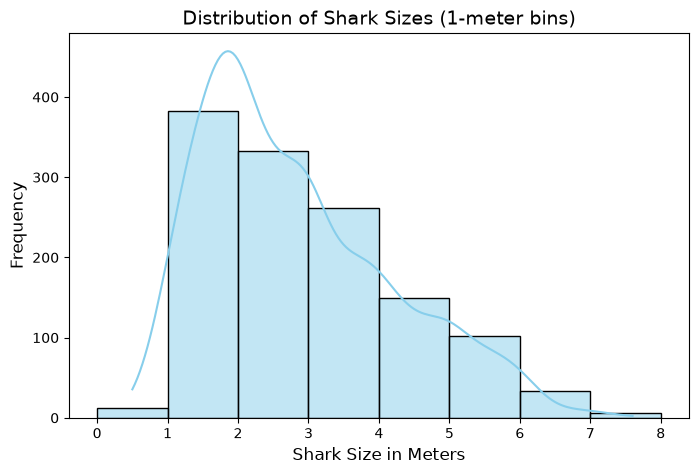

In [219]:
#split 
# Answer in write 
# Define bins with a step size of 1 meter based on existing min and max values
bin_width = 1
min_val = np.floor(min_size)  # Using the min value found earlier
max_val = np.ceil(max_size)  # Using the max value found earlier
bins = range(int(min_val), int(max_val) + bin_width, bin_width)

# Calculate frequency counts per 1-meter range
freq_table = pd.cut(size_clean, bins=bins).value_counts().sort_index()

# Display the frequency table (counts) without a graph
print('Frequency Table of Shark Sizes (1-meter bins):')
print(freq_table)

# Calculate the proportion/probability for each 1-meter range (normalized) and convert to percentages
probability_table = (
    pd.cut(size_clean, bins=bins).value_counts(normalize=True).sort_index()
)

# Display the probability distribution as percentages (multiplied by 100) per range
print('Probability Distribution of Shark Sizes in % (1-meter bins):')
print((probability_table * 100).round(2))

#Answer in graph
# Define bins with a step size of 1 meter based on existing min and max values
bin_width = 1
min_val = np.floor(min_size)  # Using the min value found earlier
max_val = np.ceil(max_size)  # Using the max value found earlier
bins = range(int(min_val), int(max_val) + bin_width, bin_width)

# Create the histogram plot with 1-meter bins using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(
    size_clean,
    bins=bins,
    kde=True,
    color='skyblue',
    edgecolor='black',
)

# Set chart title and labels
plt.title('Distribution of Shark Sizes (1-meter bins)', fontsize=14)
plt.xlabel('Shark Size in Meters', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Display the histogram
plt.show()

In [220]:
# Calculate bounds using previously found Q1, Q3, and iqr_size
if Q1 - 1.5 * iqr_size > 0:
    lower_bound_iqr = Q1 - 1.5 * iqr_size
else:
    lower_bound_iqr = 0
upper_bound_iqr = Q3 + 1.5 * iqr_size
# Filter outliers based on the IQR rule
outliers_iqr =  size_clean[(size_clean < lower_bound_iqr) | (size_clean > upper_bound_iqr)]
# Display results for IQR method
print(f'IQR Lower Bound: {lower_bound_iqr:.2f}, Upper Bound: {upper_bound_iqr:.2f}')
print(f'Number of outliers detected using IQR: {len(outliers_iqr)}')
print('Outlier values (IQR):')
print(outliers_iqr)


IQR Lower Bound: 0.00, Upper Bound: 6.55
Number of outliers detected using IQR: 7
Outlier values (IQR):
1524    7.0
2768    7.0
3609    7.0
4125    7.6
4424    7.0
4715    7.0
4832    6.7
Name: shark_size_meters, dtype: float64


In [221]:
# Compute Z-scores using previously found mean_size and std_size
z_scores = (size_clean - mean_size) / std_size

# Filter outliers where absolute Z-score is greater than 3
outliers_z = size_clean[abs(z_scores) > 3]

# Display results for Z-Score method
print(f'Number of outliers detected using Z-Score (|Z| > 3): {len(outliers_z)}')
print('Outlier values (Z-Score):')
print(outliers_z)

Number of outliers detected using Z-Score (|Z| > 3): 6
Outlier values (Z-Score):
1524    7.0
2768    7.0
3609    7.0
4125    7.6
4424    7.0
4715    7.0
Name: shark_size_meters, dtype: float64


In [222]:
# Compute modified Z-scores using previously found median_size and mad_size
modified_z_scores = 0.6745 * (size_clean - median_size) / mad_size

# Filter outliers using the MAD rule (threshold > 3.5)
outliers_mad = size_clean[abs(modified_z_scores) > 3.5]

# Display results for MAD method
print(f'Number of outliers detected using MAD (Modified Z-score > 3.5): {len(outliers_mad)}')
print('Outlier values (MAD):')
print(outliers_mad)

Number of outliers detected using MAD (Modified Z-score > 3.5): 0
Outlier values (MAD):
Series([], Name: shark_size_meters, dtype: float64)


In [223]:
# 5.2 categories data analysis
# I work on the 'spices' column, ignoring 'unknown' and NaN values

In [224]:
# Clean the species column: replace 'unknown' variations with NaN, drop missing values, and convert to string
species_clean = (gsaf_df['species'].replace(['unknown', 'Unknown'], float('nan')).dropna().astype(str))

In [225]:
# Calculate the frequency count for each unique shark species
species_freq = species_clean.value_counts()
# Calculate the frequency count for each known shark species
known_species_freq = species_freq[~species_freq.index.str.lower().str.contains('other')]

# Display the most frequent shark species and their counts
print('Most Frequent Shark Species:')
print(species_freq.head(1))

# Display the most frequent known shark species and their counts
print('Most Frequent Known Shark Species:')
print(known_species_freq.head(1))



Most Frequent Shark Species:
species
Other    1918
Name: count, dtype: int64
Most Frequent Known Shark Species:
species
White Shark    680
Name: count, dtype: int64


In [226]:
# define k for outlier detection
k=3

# Calculate the probability distribution as percentages for each shark species
species_prob = species_clean.value_counts(normalize=True) * 100

# Get the top K most frequent species and their percentages
top_k_species = species_prob.head(k)

# Calculate the total percentage of the dataset that these top K species cover
top_k_cumulative_percentage = top_k_species.sum()

# Display the results
print(f'The top {k} most frequent shark species and their percentages:')
print(top_k_species.round(2))

print(f'\nTotal percentage of the dataset covered by these top {k} species:' f' {top_k_cumulative_percentage:.2f}%')


The top 3 most frequent shark species and their percentages:
species
Other          62.07
White Shark    22.01
Tiger Shark     9.03
Name: proportion, dtype: float64

Total percentage of the dataset covered by these top 3 species: 93.11%


In [227]:
# Define the target percentage P
p = 80

# Calculate cumulative percentage of the sorted species distribution
cumulative_percentage = species_clean.value_counts(normalize=True).cumsum() * 100

# Find the minimum set of species whose cumulative percentage reaches or exceeds P
min_values_for_p = cumulative_percentage[cumulative_percentage <= p]

# If even the most frequent one is above P, we take at least 1, otherwise we take the count + 1 to cross the threshold
k_min = (
    len(min_values_for_p) + 1
    if len(min_values_for_p) < len(species_clean.value_counts())
    else len(min_values_for_p)
)

print(f'The minimum number of values to describe at least {p}% of the data is:'f' {k_min}')
print('These specific values are:')
print(species_clean.value_counts().head(k_min))

The minimum number of values to describe at least 80% of the data is: 2
These specific values are:
species
Other          1918
White Shark     680
Name: count, dtype: int64


In [228]:
# Define r for rare categories
r = 5

# Calculate the percentage distribution for each shark species
species_prob = species_clean.value_counts(normalize=True) * 100

# Filter and display only the rare categories that appear in less than 5% (< 5) of the data
rare_categories = species_prob[species_prob < r]

print(f'Rare Categories (appearing in less than {r}% of the data):')
if not rare_categories.empty:
    print(rare_categories)
else:
    print(f"No rare categories found (all species appear in {r}% or more of the data).")

Rare Categories (appearing in less than 5% of the data):
No rare categories found (all species appear in 5% or more of the data).


In [229]:
 # 6.  correlation and connectivity analysis
 # 6.1 numerical data correlation analysis
# For this analysis, I will work on the 'shark_size_meters' column, and the size_clean series created earlier, ignoring 'unknown' and NaN values

In [230]:
#calculat e correlation between shark size and day of the month, ignoring 'unknown' and NaN values
# Convert to numeric and drop missing values inline
s_day = pd.to_numeric(gsaf_df['day'].replace('unknown', None), errors='coerce')

# Calculate Pearson, Spearman, and Kendall correlation for the 'shark_size_meters' and 'day' columns 
print('Pearson:', size_clean.corr(s_day, method='pearson').round(2))
print('Spearman:', size_clean.corr(s_day, method='spearman').round(2))
print('Kendall:', size_clean.corr(s_day, method='kendall').round(2))

Pearson: 0.02
Spearman: 0.03
Kendall: 0.02


In [231]:
# List of activity binary columns
activities = ['act_diving', 'act_swimming', 'act_fishing']

# Calculate Pearson, Spearman, and Kendall correlation for each activity and the 'shark_size_meters' column
for act in activities:
  s_act = pd.to_numeric(gsaf_df[act], errors='coerce')

  # Pairwise correlation calculations
  pearson = size_clean.corr(s_act, method='pearson')
  spearman = size_clean.corr(s_act, method='spearman')
  kendall = size_clean.corr(s_act, method='kendall')

  print(f'Correlation: shark_size_meters vs {act}')
  print(f'Pearson : {pearson:.2f}')
  print(f'Spearman: {spearman:.2f}')
  print(f'Kendall : {kendall:.2f}\n')

Correlation: shark_size_meters vs act_diving
Pearson : -0.02
Spearman: -0.01
Kendall : -0.01

Correlation: shark_size_meters vs act_swimming
Pearson : -0.09
Spearman: -0.10
Kendall : -0.08

Correlation: shark_size_meters vs act_fishing
Pearson : 0.01
Spearman: 0.01
Kendall : 0.00



In [232]:
# create a correlation matrix for the selected columns, ignoring
# Define the list of 5 target columns
corr_cols = [
    'act_diving',
    'act_swimming',
    'act_fishing',
    'day',
    'shark_size_meters',
]

# Clean selected columns: replace 'unknown' with None and convert to numeric float
corr_df = gsaf_df[corr_cols].apply(
    lambda col: pd.to_numeric(col.replace(['unknown', 'Unknown'], None), errors='coerce'))

# Calculate Pearson correlation matrix
corr_matrix = corr_df.corr(method='pearson')

# Display the correlation matrix
print('Correlation Matrix:')
print(corr_matrix.round(2))

Correlation Matrix:
                   act_diving  act_swimming  act_fishing   day  \
act_diving               1.00         -0.08        -0.08 -0.00   
act_swimming            -0.08          1.00        -0.22  0.01   
act_fishing             -0.08         -0.22         1.00 -0.02   
day                     -0.00          0.01        -0.02  1.00   
shark_size_meters       -0.02         -0.09         0.01  0.02   

                   shark_size_meters  
act_diving                     -0.02  
act_swimming                   -0.09  
act_fishing                     0.01  
day                             0.02  
shark_size_meters               1.00  


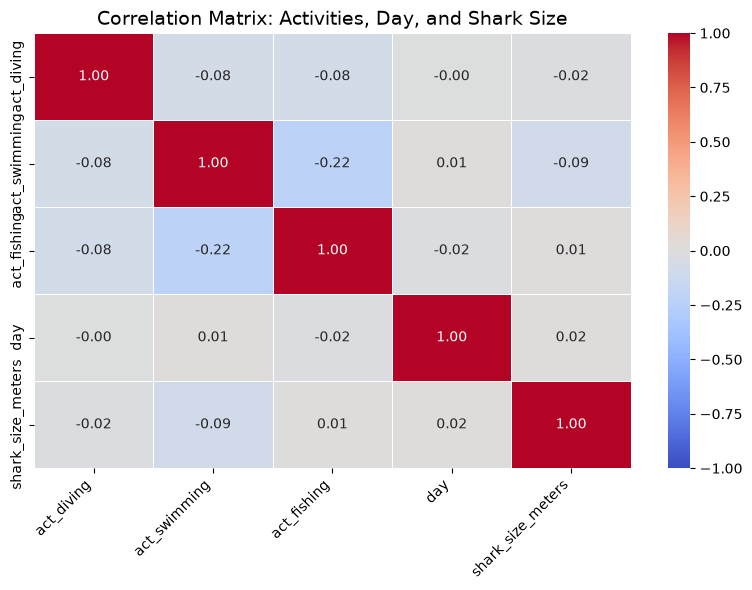

In [233]:
# create a heatmap for visual correlation analysis
# Plot the heatmap for visual correlation analysis
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

# Set chart title and adjust layout
plt.title('Correlation Matrix: Activities, Day, and Shark Size', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Display heatmap
plt.show()

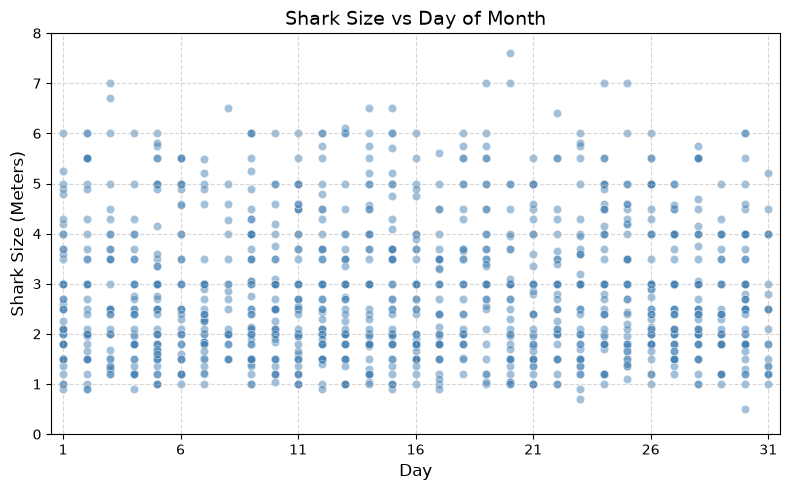

In [234]:
# Scatter Plot: Shark Size vs Day (Chronological X-axis 1 to 31)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=s_day, y=size_clean, ax=ax, alpha=0.5, color='steelblue')

ax.set_xlim(0.5, 31.5)
ax.set_xticks(range(1, 32, 5))  
ax.set_ylim(0, 8)
ax.set_yticks(np.arange(0, 9, 1))  

ax.set_title('Shark Size vs Day of Month', fontsize=14)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Shark Size (Meters)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('scatter_shark_vs_day.png')

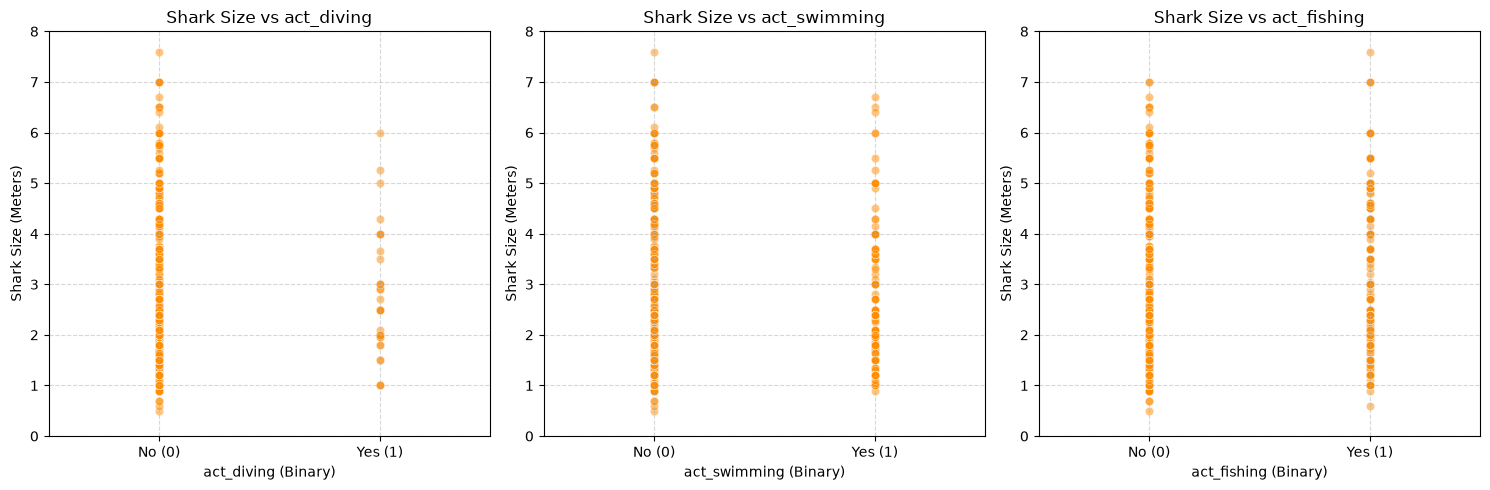

In [235]:

# Scatter Plots (Subplots) for Shark Size vs Binary Activities
activities = ['act_diving', 'act_swimming', 'act_fishing']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, act in enumerate(activities):
  s_act = pd.to_numeric(gsaf_df[act], errors='coerce')
  sns.scatterplot(
      x=s_act, y=size_clean, ax=axes[i], alpha=0.5, color='darkorange'
  )

  axes[i].set_xlim(-0.5, 1.5)
  axes[i].set_xticks([0, 1])
  axes[i].set_xticklabels(['No (0)', 'Yes (1)'])

  axes[i].set_ylim(0, 8)
  axes[i].set_yticks(np.arange(0, 9, 1))  

  axes[i].set_title(f'Shark Size vs {act}', fontsize=12)
  axes[i].set_xlabel(f'{act} (Binary)', fontsize=10)
  axes[i].set_ylabel('Shark Size (Meters)', fontsize=10)
  axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('scatter_shark_vs_activities.png')

Contingency Table (Frequency Table)


time_of_day,Afternoon,Evening,Morning,Night,unknown,All
size_category,,,,,,
Small,162,22,127,11,177,499
Medium,201,28,148,5,175,557
Large,84,3,70,4,63,224
All,447,53,345,20,415,1280


<Figure size 900x500 with 0 Axes>

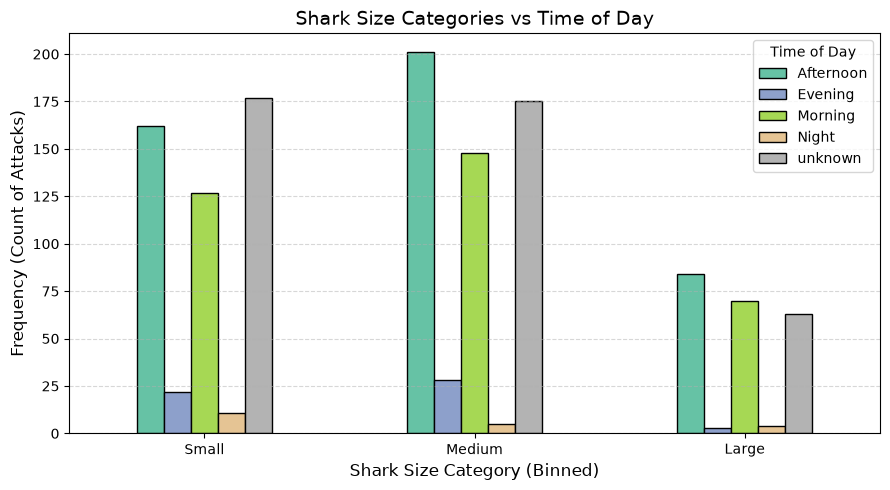

In [236]:
# Contingency Table: Shark Size Categories vs. Time of Day
# Define bin edges and labels for shark size categories
bins = [0, 2.0, 4.0, 10.0]  # Example thresholds in meters
labels = ['Small', 'Medium', 'Large']

# Add the new categorical binned column to the dataframe
gsaf_df['size_category'] = pd.cut(size_clean, bins=bins, labels=labels, include_lowest=True)

# Create Frequency Table (Crosstab) between the binned size and time_of_day
crosstab_table = pd.crosstab(
    gsaf_df['size_category'], gsaf_df['time_of_day'], margins=True)

print('Contingency Table (Frequency Table)')
display(crosstab_table)

# Visualize the relationship using a grouped bar chart
plt.figure(figsize=(9, 5))
pd.crosstab(gsaf_df['size_category'], gsaf_df['time_of_day']).plot(
    kind='bar', figsize=(9, 5), colormap='Set2', edgecolor='black')

plt.title('Shark Size Categories vs Time of Day', fontsize=14)
plt.xlabel('Shark Size Category (Binned)', fontsize=12)
plt.ylabel('Frequency (Count of Attacks)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Time of Day')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Contingency Table (Frequency Table)


species,Bull Shark,Other,Tiger Shark,Unknown,White Shark,All
size_category,,,,,,
Small,33,421,19,6,20,499
Medium,40,251,72,2,192,557
Large,0,47,15,0,162,224
All,73,719,106,8,374,1280


<Figure size 900x500 with 0 Axes>

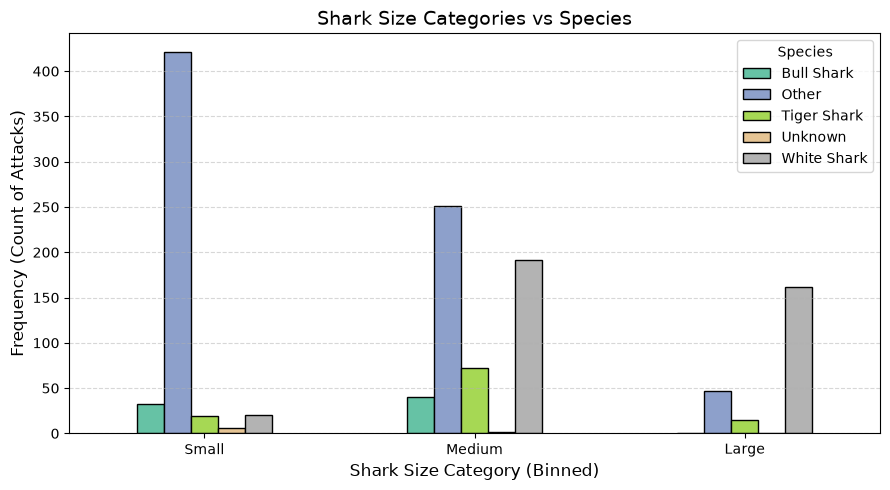

In [237]:
# Contingency Table: Shark Size Categories vs. Species
# Clean numerical shark size and create bins (Categorical conversion)
# Define bin edges and labels for shark size categories
bins = [0, 2.0, 4.0, 10.0]  # Example thresholds in meters
labels = ['Small', 'Medium', 'Large']

# Add the new categorical binned column to the dataframe
gsaf_df['size_category'] = pd.cut(
    size_clean, bins=bins, labels=labels, include_lowest=True
)

# Create Frequency Table (Crosstab) between the binned size and species
crosstab_table = pd.crosstab(
    gsaf_df['size_category'], gsaf_df['species'], margins=True
)

print('Contingency Table (Frequency Table)')
display(crosstab_table)

# Visualize the relationship using a grouped bar chart
plt.figure(figsize=(9, 5))
pd.crosstab(gsaf_df['size_category'], gsaf_df['species']).plot(
    kind='bar', figsize=(9, 5), colormap='Set2', edgecolor='black'
)

plt.title('Shark Size Categories vs Species', fontsize=14)
plt.xlabel('Shark Size Category (Binned)', fontsize=12)
plt.ylabel('Frequency (Count of Attacks)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Species')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

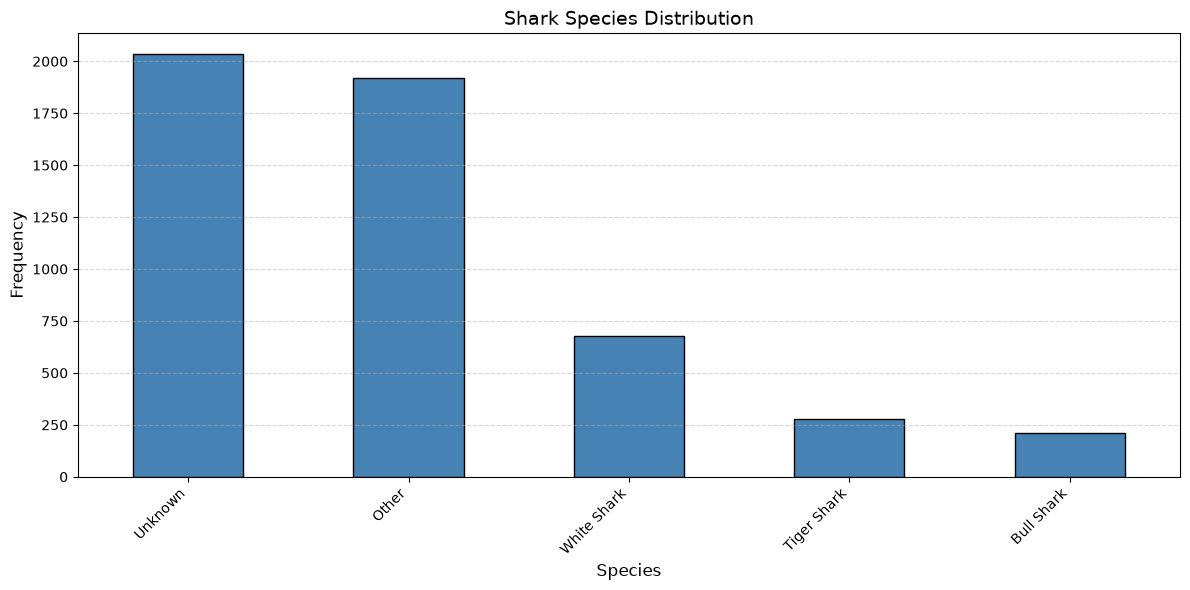

In [238]:
# bar chart for species distribution
# Count values of the species column
species_counts = gsaf_df['species'].value_counts()

# Create bar chart
plt.figure(figsize=(12, 6))
species_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Shark Species Distribution', fontsize=14)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

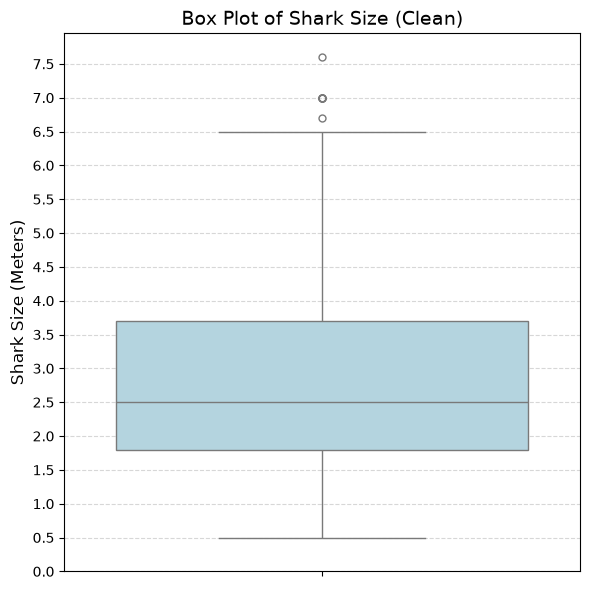

In [239]:
# box plot for shark size distribution
# Create box plot for size_clean
plt.figure(figsize=(6, 6))
sns.boxplot(y=size_clean, color='lightblue', fliersize=5)

# Set Y-axis ticks with a step size of 0.5 (from 0 to max value)
plt.yticks(np.arange(0, int(size_clean.max()) + 1, 0.5))

plt.title('Box Plot of Shark Size (Clean)', fontsize=14)
plt.ylabel('Shark Size (Meters)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\idane\AppData\Local\Temp\ipykernel_21688\2359283340.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


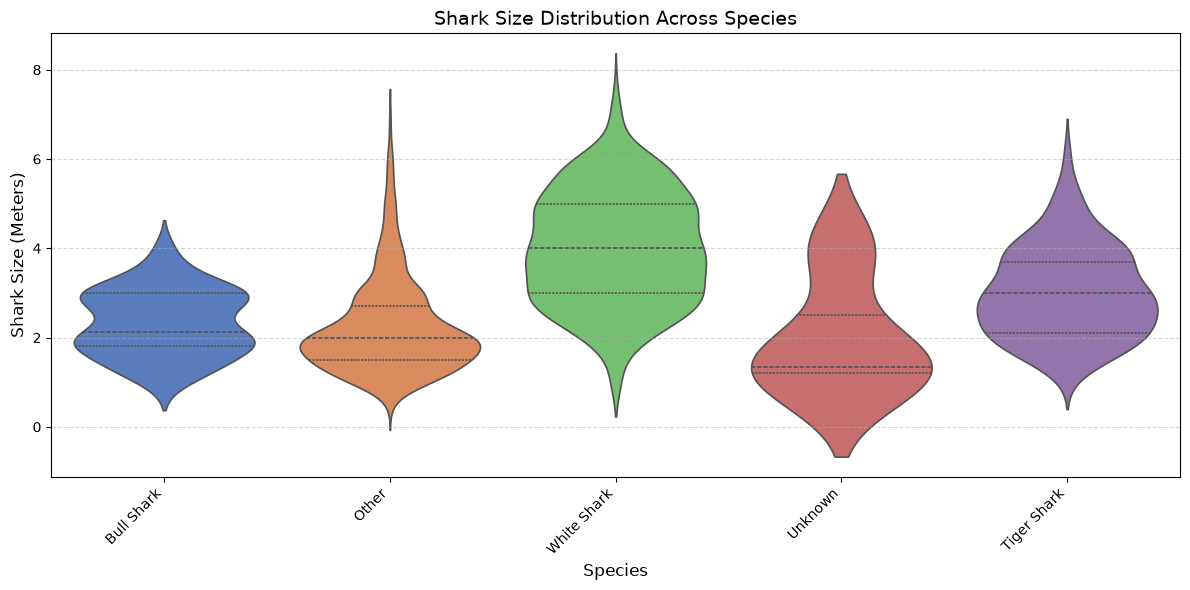

In [240]:
# violin plot for shark size distribution across species
# Add the cleaned size series directly as a column inside gsaf_df
gsaf_df['size_clean'] = size_clean

# Now Seaborn will find both 'species' and 'size_clean' inside the DataFrame
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='species',
    y='size_clean',
    data=gsaf_df,
    palette='muted',
    inner='quartile',
)

plt.title('Shark Size Distribution Across Species', fontsize=14)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Shark Size (Meters)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

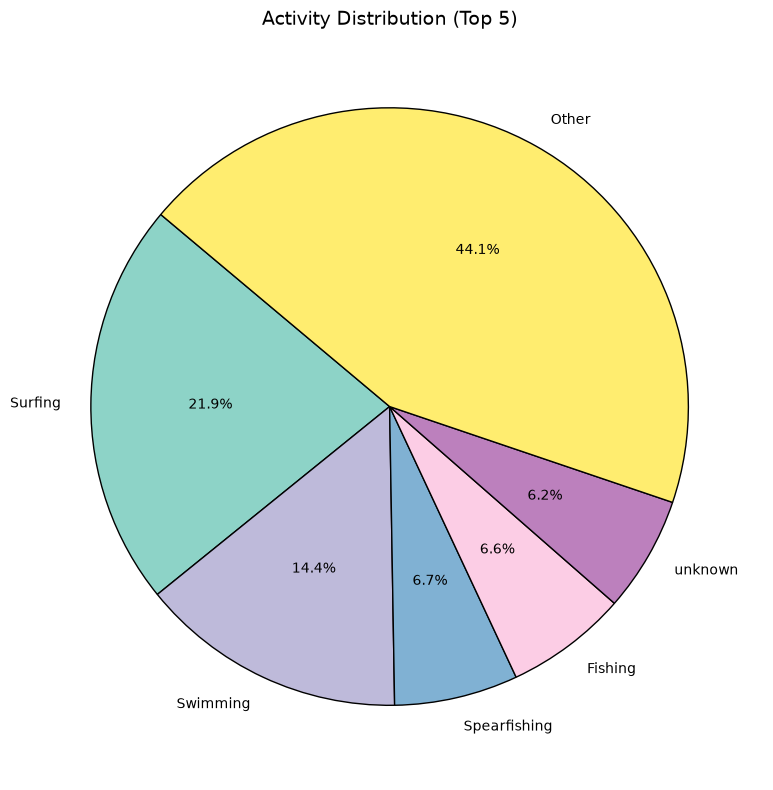

In [ ]:
#pie chart for activity distribution

# Get value counts of the activity column
activity_counts = gsaf_df['activity'].value_counts()

# Keep top 5 most common activities and group the rest into 'Other'
top_activities = activity_counts.head(5)
other_sum = activity_counts.iloc[5:].sum()
if other_sum > 0:
  top_activities['Other'] = other_sum

# Create pie chart
plt.figure(figsize=(8, 8))
top_activities.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colormap='Set3',
    wedgeprops={'edgecolor': 'black'},
)

plt.title('Activity Distribution (Top 5)', fontsize=14)

plt.tight_layout()
plt.show()

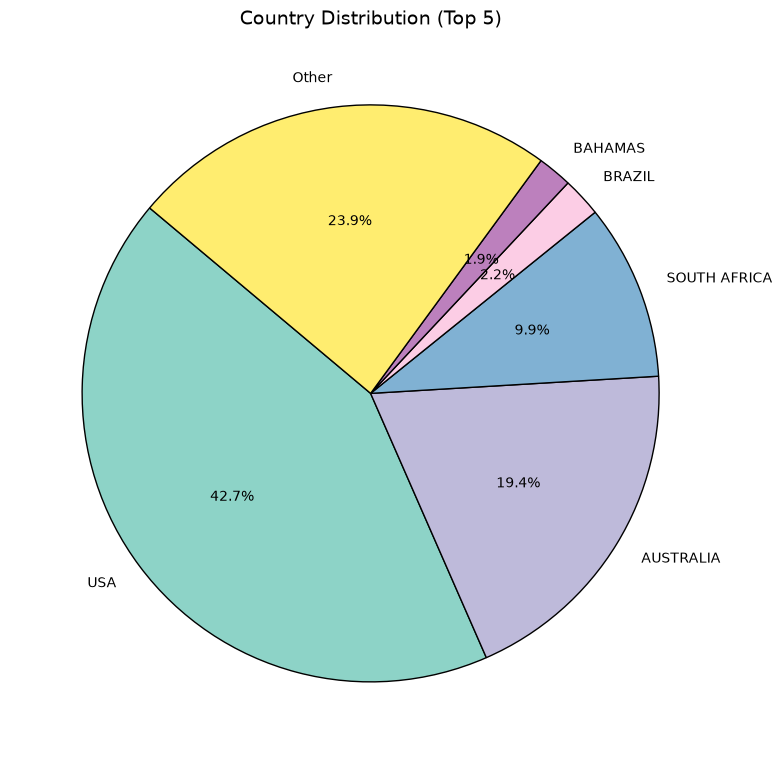

In [262]:
#pie chart for country distribution

# Get value counts of the country column
country_counts = gsaf_df['country'].value_counts()

# Keep top 5 most common countries and group the rest into 'Other'
top_countries = country_counts.head(5)
other_sum = country_counts.iloc[5:].sum()
if other_sum > 0:
  top_countries['Other'] = other_sum

# Create pie chart
plt.figure(figsize=(8, 8))
top_countries.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colormap='Set3',
    wedgeprops={'edgecolor': 'black'},
)

plt.title('Country Distribution (Top 5)', fontsize=14)

plt.tight_layout()
plt.show()

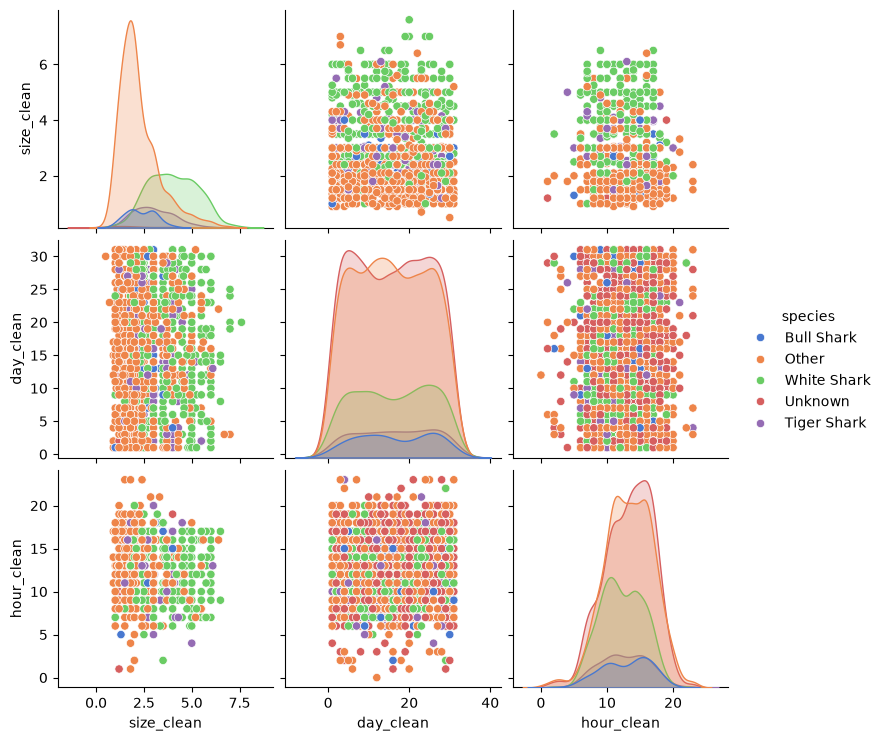

In [251]:
#pairplot for numerical features and species hue

# create day_clean series consistently (replacing 'unknown' and converting to numeric)
day_clean = pd.to_numeric(gsaf_df['day'].astype(str).str.strip().str.lower().replace('unknown', np.nan),errors='coerce')

# Ensure the cleaned series are saved as actual columns inside gsaf_df
gsaf_df['day_clean'] = day_clean
gsaf_df['hour_clean'] = hour_clean

# 2. Define numerical features and species hue
numeric_features = ['size_clean', 'day_clean', 'hour_clean']
hue_column = 'species'

# 3. Create the multi-variable pairplot grid
pairplot_grid = sns.pairplot(
    gsaf_df[numeric_features + [hue_column]],
    hue=hue_column,
    palette='muted',
    diag_kind='kde',
)

plt.show()

In [259]:
import pandas as pd

# Flag to track if any sorted column was found
is_sorted_found = False

# Loop through all columns in the dataframe to check if data is sorted by any of them
for col in gsaf_df.columns:
  try:
    if gsaf_df[col].is_monotonic_increasing:
      print(f"-> Column '{col}' is sorted in ASCENDING order.")
      is_sorted_found = True
    elif gsaf_df[col].is_monotonic_decreasing:
      print(f"-> Column '{col}' is sorted in DESCENDING order.")
      is_sorted_found = True
  except Exception:
    pass

# If no sorted column was found across the entire dataframe
if not is_sorted_found:
  print("No columns in the dataframe are sorted in either ascending or descending order.")

No columns in the dataframe are sorted in either ascending or descending order.


C:\Users\idane\AppData\Local\Temp\ipykernel_21688\2225144523.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


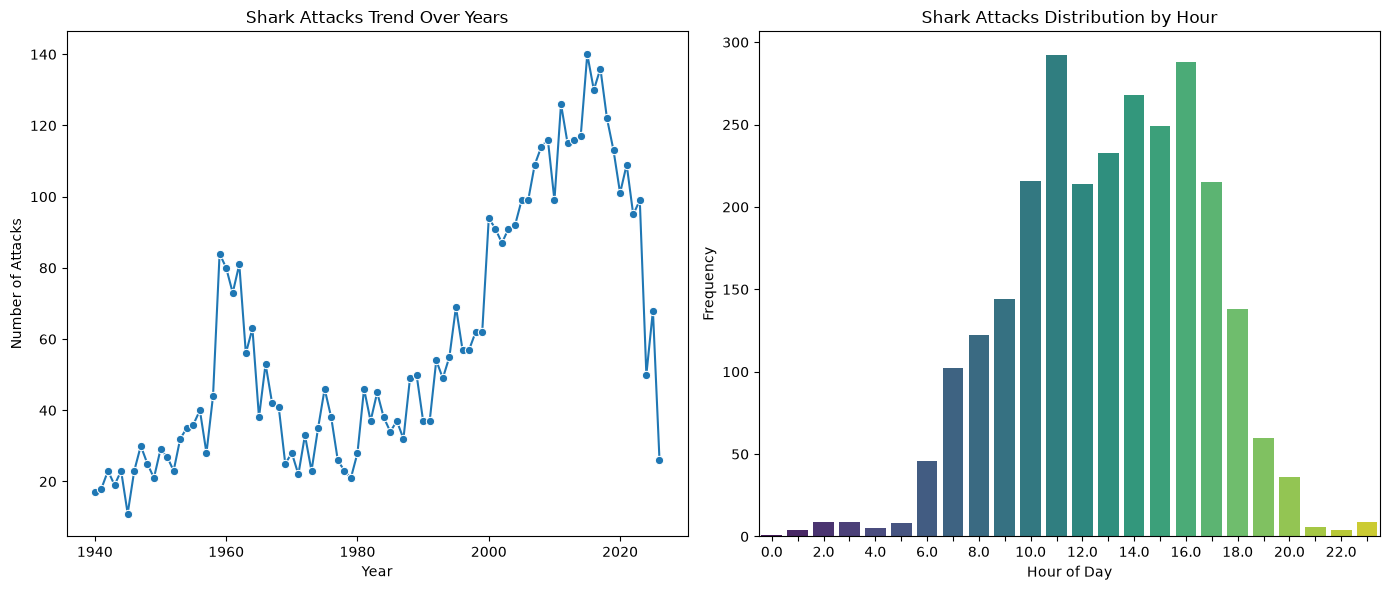

In [261]:
# Create the figure
plt.figure(figsize=(14, 6))

# Subplot 1: Attacks over the Years
plt.subplot(1, 2, 1)
yearly_attacks = gsaf_df['year'].value_counts().sort_index()
sns.lineplot(x=yearly_attacks.index, y=yearly_attacks.values, marker='o')
plt.title('Shark Attacks Trend Over Years', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Number of Attacks')

# Subplot 2: Attacks by Hour of Day with spaced x-axis ticks (every 2 numbers)
plt.subplot(1, 2, 2)
hourly_attacks = gsaf_df['hour_clean'].value_counts().sort_index()

ax = sns.barplot(
    x=hourly_attacks.index, y=hourly_attacks.values, palette='viridis'
)

# Set ticks to show every 2nd label while keeping all data intact
for index, label in enumerate(ax.get_xticklabels()):
  if index % 2 != 0:
    label.set_visible(False)

plt.title('Shark Attacks Distribution by Hour', fontsize=12)
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [276]:
#  DEFINING THE HYPOTHESES (Conceptual)
# ==========================================
# Null Hypothesis (H0): There is NO association between time of day and shark species. (They are independent).
# Alternative Hypothesis (H1): There IS a statistically significant association between time of day and shark species.

# 1. Prepare time periods from hour_clean
def categorize_time(hour):
    if pd.isna(hour):
        return 'Unknown'
    elif 6 <= hour < 18:
        return 'Daytime'
    else:
        return 'Night/Evening'

gsaf_df['time_period'] = gsaf_df['hour_clean'].apply(categorize_time)

# Filter out unknown values
test_df = gsaf_df[gsaf_df['time_period'] != 'Unknown']

# 2. Build the Observed Table (Actual data from the dataset)
observed_table = pd.crosstab(test_df['time_period'], test_df['species'])

# 3. Perform Chi-Squared Test of Independence
chi2_stat, p_value, dof, expected_freq = chi2_contingency(observed_table)

# 4. Print both tables for comparison
print("1. OBSERVED TABLE (Actual Data from Dataset) ===")
print(observed_table)

print("\n2. EXPECTED TABLE (Theoretical counts if data was random) ===")
expected_table_df = pd.DataFrame(expected_freq, index=observed_table.index, columns=observed_table.columns)
print(expected_table_df)

# 5. Print final test results
print(f"\nChi-Squared Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Reject H0. There is a strong, significant association between time of day and species.")
else:
    print("Result: Fail to reject H0. No significant association found.")
  

1. OBSERVED TABLE (Actual Data from Dataset) ===
species        Bull Shark  Other  Tiger Shark  Unknown  White Shark
time_period                                                        
Daytime               129    802          152      845          461
Night/Evening          12    124           19      112           22

2. EXPECTED TABLE (Theoretical counts if data was random) ===
species        Bull Shark       Other  Tiger Shark     Unknown  White Shark
time_period                                                                
Daytime        125.783794  826.069455   152.546303  853.724048     430.8764
Night/Evening   15.216206   99.930545    18.453697  103.275952      52.1236

Chi-Squared Statistic: 27.6202
P-value: 0.0000
Result: Reject H0. There is a strong, significant association between time of day and species.
